In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dirty_cafe_sales.csv')

In [ ]:
df.shape

(10000, 8)

In [ ]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [ ]:
df

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
3,TXN_7034554,Salad,2,5.0,10.0,Other,Delivery,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Delivery,2023-03-31
...,...,...,...,...,...,...,...,...
9992,TXN_2739140,Smoothie,4,4.0,16.0,Other,In-store,2023-07-05
9994,TXN_7851634,Other,4,4.0,16.0,Other,Delivery,2023-01-08
9995,TXN_7672686,Coffee,2,2.0,4.0,Other,Delivery,2023-08-30
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,Delivery,2023-03-02


In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

In [ ]:
df['payment_method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan],
      dtype=object)

In [ ]:
# Normalize payment_method
df["payment_method"] = df["payment_method"].replace(
    ["UNKNOWN", "ERROR"], np.nan
)

df["payment_method"] = df["payment_method"].fillna("Other")

df["payment_method"].value_counts()

,count
payment_method,
Other,3178
Digital Wallet,2291
Credit Card,2273
Cash,2258


In [ ]:
# Remove rows where total_spent is invalid
df["total_spent"] = pd.to_numeric(df["total_spent"], errors="coerce")

df = df.dropna(subset=["total_spent"])

df.shape

# Ensure total_spent is valid and non-negative
df["total_spent"] = pd.to_numeric(df["total_spent"], errors="coerce")

df = df.dropna(subset=["total_spent"])
df = df[df["total_spent"] >= 0]

df.shape

/tmp/ipykernel_223/1636701379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_spent"] = pd.to_numeric(df["total_spent"], errors="coerce")


(9498, 8)

In [ ]:
# Normalize item values
df["item"] = (
    df["item"]
      .replace(["ERROR", "UNKNOWN", "add-ons"], np.nan)
      .fillna("Other")
)

df["item"].value_counts()

,count
item,
Coffee,1115
Juice,1115
Salad,1096
Cake,1088
Sandwich,1065
Tea,1041
Cookie,1035
Smoothie,1024
Other,919


In [ ]:
# Fix price_per_unit and show item-wise prices
df["price_per_unit"] = pd.to_numeric(df["price_per_unit"], errors="coerce")

df = df.dropna(subset=["price_per_unit"])

item_price = (
    df.groupby("item", as_index=False)
      .agg(
          count=("price_per_unit", "count"),
          min_price=("price_per_unit", "min"),
          max_price=("price_per_unit", "max"),
          avg_price=("price_per_unit", "mean")
      )
      .sort_values("avg_price", ascending=False)
)

item_price

,item,count,min_price,max_price,avg_price
5,Salad,1031,5.0,5.0,5.00000
7,Smoothie,967,4.0,4.0,4.00000
6,Sandwich,1020,4.0,4.0,4.00000
0,Cake,1035,3.0,3.0,3.00000
3,Juice,1055,3.0,3.0,3.00000
4,Other,868,1.0,5.0,2.94182
1,Coffee,1059,2.0,2.0,2.00000
8,Tea,978,1.5,1.5,1.50000
2,Cookie,972,1.0,1.0,1.00000


In [ ]:
# Handle missing price_per_unit values

# ensure numeric
df["price_per_unit"] = pd.to_numeric(df["price_per_unit"], errors="coerce")

# fill NaNs using item-wise median, fallback to global median
global_median = df["price_per_unit"].median()

df["price_per_unit"] = (
    df.groupby("item")["price_per_unit"]
      .transform(lambda x: x.fillna(x.median() if not np.isnan(x.median()) else global_median))
)

df["price_per_unit"].isna().sum()

/tmp/ipykernel_223/3377384717.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_per_unit"] = pd.to_numeric(df["price_per_unit"], errors="coerce")
/tmp/ipykernel_223/3377384717.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_per_unit"] = (


np.int64(0)

In [ ]:
df

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
3,TXN_7034554,Salad,2,5.0,10.0,Other,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
...,...,...,...,...,...,...,...,...
9992,TXN_2739140,Smoothie,4,4.0,16.0,Other,In-store,2023-07-05
9994,TXN_7851634,Other,4,4.0,16.0,Other,NaN,2023-01-08
9995,TXN_7672686,Coffee,2,2.0,4.0,Other,UNKNOWN,2023-08-30
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02


In [ ]:
df[
    'location'
].unique()

array(['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR'], dtype=object)

In [ ]:
# Normalize location values
df["location"] = (
    df["location"]
      .replace(["UNKNOWN", "ERROR"], np.nan)
      .fillna("Other")
)

df["location"].value_counts()

/tmp/ipykernel_223/3199016005.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["location"] = (


,count
location,
Other,3547
In-store,2723
Takeaway,2715


In [ ]:
# Map invalid / missing locations to Delivery
df["location"] = (
    df["location"]
      .replace(['Other'], np.nan)
      .fillna("Delivery")
)

df["location"].value_counts()

/tmp/ipykernel_223/2335548788.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["location"] = (


,count
location,
Delivery,3547
In-store,2723
Takeaway,2715


In [ ]:
df.describe()

,price_per_unit,total_spent
count,8985.000000,8985.000000
mean,2.947524,8.917418
std,1.278853,6.002923
min,1.000000,1.000000
25%,2.000000,4.000000
50%,3.000000,8.000000
75%,4.000000,12.000000
max,5.000000,25.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8985 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    8985 non-null   object        
 1   item              8985 non-null   object        
 2   quantity          8860 non-null   object        
 3   price_per_unit    8985 non-null   float64       
 4   total_spent       8985 non-null   float64       
 5   payment_method    8985 non-null   object        
 6   location          8985 non-null   object        
 7   transaction_date  8577 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 631.8+ KB


In [ ]:
# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

df["transaction_date"].dtype

/tmp/ipykernel_223/1688614849.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transaction_date"] = pd.to_datetime(


dtype('<M8[ns]')

/tmp/ipykernel_223/1186220521.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year_month"] = df["transaction_date"].dt.to_period("M")


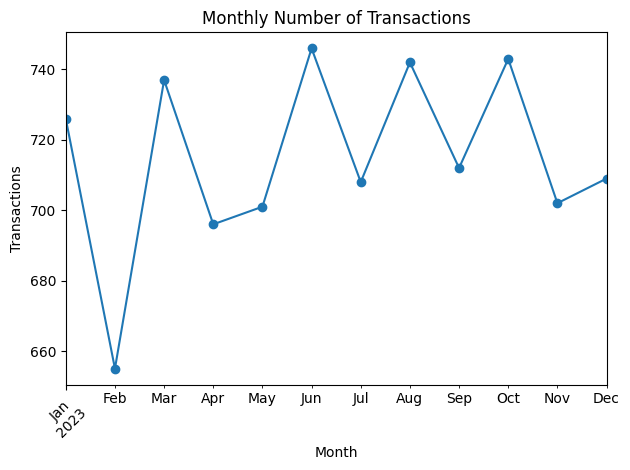

In [ ]:
# common month column
df["year_month"] = df["transaction_date"].dt.to_period("M")

# =========================
# 1. Monthly transactions
# =========================
monthly_txn = (
    df.groupby("year_month")["transaction_id"]
      .count()
      .sort_index()
)

plt.figure()
monthly_txn.plot(marker="o")
plt.title("Monthly Number of Transactions")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_223/1588410531.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year_month"] = df["transaction_date"].dt.to_period("M")


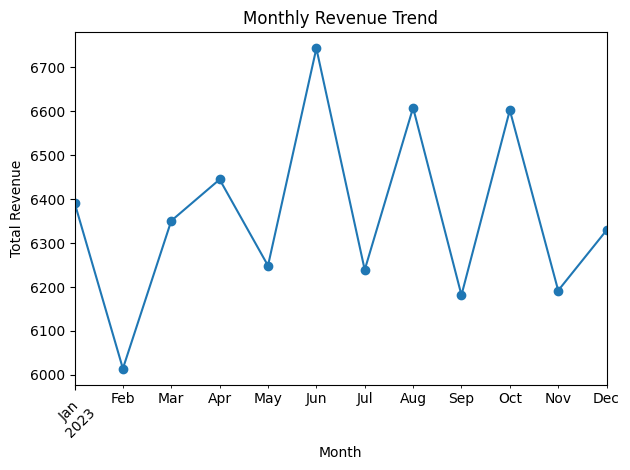

In [ ]:
# =========================
# Monthly revenue trend (clean, readable)
# =========================
df["year_month"] = df["transaction_date"].dt.to_period("M")

monthly_revenue = (
    df.groupby("year_month")["total_spent"]
      .sum()
      .sort_index()
)

plt.figure()
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

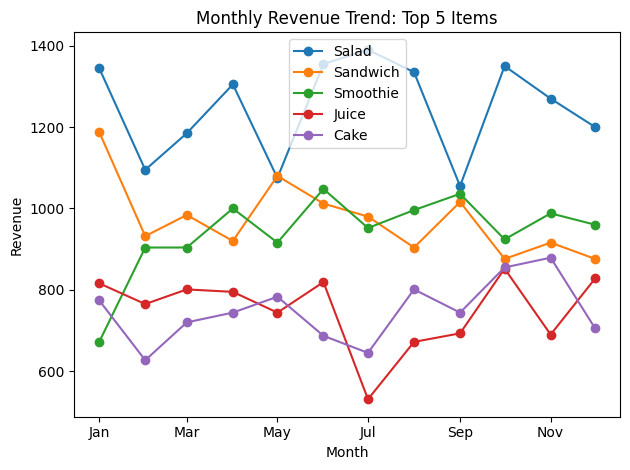

In [ ]:
# =========================
# Monthly top items by revenue (Jan, Feb format)
# =========================

monthly_item_revenue = (
    df.groupby(["year_month", "item"])["total_spent"]
      .sum()
      .reset_index()
)

top_items = (
    monthly_item_revenue.groupby("item")["total_spent"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = monthly_item_revenue[monthly_item_revenue["item"].isin(top_items)]

plt.figure()

for item in top_items:
    temp = filtered[filtered["item"] == item]
    plt.plot(
        temp["year_month"].dt.to_timestamp(),
        temp["total_spent"],
        marker="o",
        label=item
    )

plt.title("Monthly Revenue Trend: Top 5 Items")
plt.xlabel("Month")
plt.ylabel("Revenue")

# ---- FIX MONTH LABELS ----
plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b")
)

plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

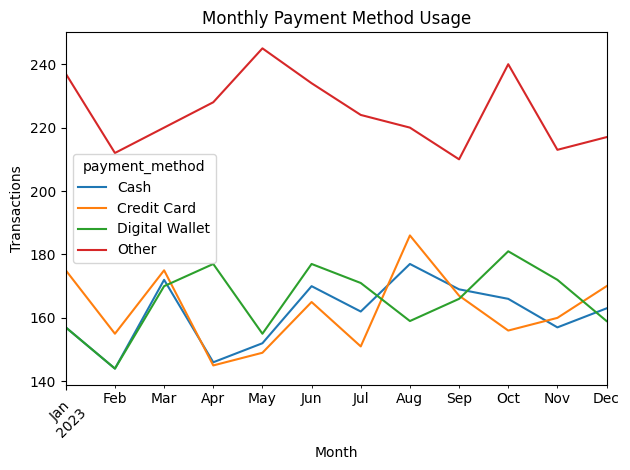

In [ ]:
# =========================
# 4. Monthly payment method usage
# =========================
monthly_payment = (
    df.groupby(["year_month", "payment_method"])["transaction_id"]
      .count()
      .unstack(fill_value=0)
)

plt.figure()
monthly_payment.plot()
plt.title("Monthly Payment Method Usage")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

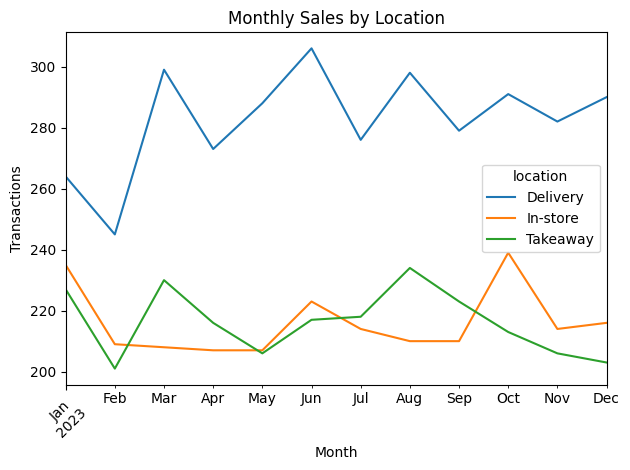

In [ ]:
# =========================
# 5. Monthly location distribution
# =========================
monthly_location = (
    df.groupby(["year_month", "location"])["transaction_id"]
      .count()
      .unstack(fill_value=0)
)

plt.figure()
monthly_location.plot()
plt.title("Monthly Sales by Location")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


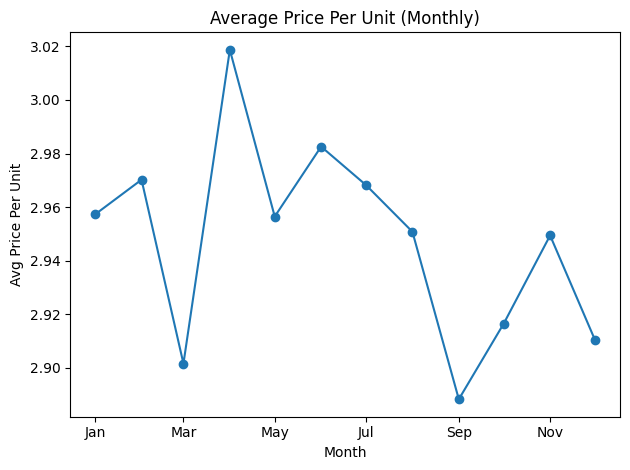

In [ ]:
# =========================
# Monthly average price per unit
# =========================
monthly_price = (
    df.groupby("year_month")["price_per_unit"]
      .mean()
      .sort_index()
)

plt.figure()
plt.plot(
    monthly_price.index.to_timestamp(),
    monthly_price.values,
    marker="o"
)

plt.title("Average Price Per Unit (Monthly)")
plt.xlabel("Month")
plt.ylabel("Avg Price Per Unit")

plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b")
)

plt.tight_layout()
plt.show()

In [ ]:
'''
`june month has the most number of transactions.
`monthly revenue fluctuates monthly, specifically from may tro november.
`most revenue was generated in june and the least in february.
`top 5 items are salad, sandwich, smoothie, juice and cake.
`most used payment method is "other".
`most orders are served using the delivery method followed by takeaway.
'''



'\n`june month has the most number of transactions.\n`monthly revenue fluctuates monthly, specifically from may tro november. \n`most revenue was generated in june and the least in february.\n`top 5 items are salad, sandwich, smoothie, juice and cake.\n`most used payment method is "other".\n`most orders are served using the delivery method followed by takeaway.\n'

In [ ]:
df.to_csv('cof.csv', index=False)